# 10d — Externality comparative statics

Five comparative-statics variants of the same linear social-marginal-
benefit (SMB) / social-marginal-cost (SMC) diagram, illustrating what
happens to the market equilibrium — and to two different deadweight-
loss measures — when either curve shifts:

- **Sections 1, 4**: SMC shifts up (SMB fixed), at two different sets
  of curve slopes/intercepts.
- **Section 2**: SMB shifts down (SMC fixed).
- **Section 3**: SMB shifts up (SMC fixed).
- **Section 5**: SMB shifts down (SMC fixed), same slopes as Section 4.

All five share an identical underlying construction, so they are built
here via one shared parametrized helper function rather than five
near-duplicate code blocks. For each pair of curves (original vs.
shifted), five points are located: $A$ (original equilibrium), $B$ (new
equilibrium), $C$ (the *new* curve evaluated at the *old* equilibrium
quantity $q_1^{\star}$), and $E$/$D$ (the new curve, resp. the fixed
curve, evaluated at the quantity where the new curve reaches the *old*
equilibrium price $p_1^{\star}$). Two deadweight-loss triangles are then
shaded: $\mathrm{DWL}(q_1^{\star})$ (triangle $A$-$B$-$C$, the loss from
holding *quantity* fixed at the old optimum despite the shift) and
$\mathrm{DWL}(p_2^{\star})$ (triangle $B$-$E$-$D$, the loss from holding
*price* fixed at the old optimum instead). All self-contained
(hardcoded linear curves, no external data).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

color_blue = "#1f77b4"
color_green = "#2ca02c"
color_red = "#d62728"
color_violet = "#9467bd"
color_black = "#000000"

def smb(q, alpha, beta):
    return alpha - beta * q

def smc(q, alpha, beta):
    return alpha + beta * q

def intersect(alpha_B, beta_B, alpha_C, beta_C):
    q = (alpha_B - alpha_C) / (beta_B + beta_C)
    p = (alpha_B * beta_C + alpha_C * beta_B) / (beta_B + beta_C)
    return q, p

def dwl_shift_diagram(shift, params1, params2, point_offsets, point_labels,
                       curve_labels, legend_loc, use_latex_points=False):
    """Shared construction for the five comparative-statics diagrams below.

    shift: 'cost' (SMC shifts, SMB fixed) or 'benefit' (SMB shifts, SMC fixed).
    params1: (alpha_B, beta_B, alpha_C1, beta_C1) — the fixed curve plus the
      *original* version of the shifting curve.
    params2: (alpha_C2, beta_C2) if shift == 'cost', or (alpha_B2, beta_B2)
      if shift == 'benefit' — the *shifted* version of the shifting curve.
    """
    q = np.arange(0, 22.01, 0.5)
    alpha_B, beta_B, alpha_C1, beta_C1 = params1

    if shift == "cost":
        alpha_C2, beta_C2 = params2
        curve_fixed_y = smb(q, alpha_B, beta_B)
        curve_v1_y = smc(q, alpha_C1, beta_C1)
        curve_v2_y = smc(q, alpha_C2, beta_C2)
        qA, pA = intersect(alpha_B, beta_B, alpha_C1, beta_C1)
        qB, pB = intersect(alpha_B, beta_B, alpha_C2, beta_C2)
        pE = pA
        qE = (pE - alpha_C2) / beta_C2
        qD, pD = qE, smb(qE, alpha_B, beta_B)
        qC, pC = qA, smc(qA, alpha_C2, beta_C2)
    else:
        alpha_B2, beta_B2 = params2
        curve_fixed_y = smc(q, alpha_C1, beta_C1)
        curve_v1_y = smb(q, alpha_B, beta_B)
        curve_v2_y = smb(q, alpha_B2, beta_B2)
        qA, pA = intersect(alpha_B, beta_B, alpha_C1, beta_C1)
        qB, pB = intersect(alpha_B2, beta_B2, alpha_C1, beta_C1)
        pE = pA
        qE = (alpha_B2 - pE) / beta_B2
        qD, pD = qE, smc(qE, alpha_C1, beta_C1)
        qC, pC = qA, smb(qA, alpha_B2, beta_B2)

    fig, ax = plt.subplots(figsize=(8, 8))
    # Color convention: blue is always the SMB-side curve at its original
    # level (the fixed SMB when SMC is shifting, or SMB1 when SMB itself is
    # shifting), green is always the SMC-side curve at its original level,
    # and red is always the shifted (v2) curve, whichever side it's on.
    if shift == "cost":
        blue_y, green_y = curve_fixed_y, curve_v1_y
    else:
        blue_y, green_y = curve_v1_y, curve_fixed_y
    ax.plot(q, blue_y, color=color_blue, lw=1.5)
    ax.plot(q, green_y, color=color_green, lw=1.5)
    ax.plot(q, curve_v2_y, color=color_red, lw=1.5)

    # dotted guide lines to A and B
    ax.plot([0, qA], [pA, pA], ":", color=color_black, lw=1.5)
    ax.plot([qA, qA], [0, pA], ":", color=color_black, lw=1.5)
    ax.plot([0, qB], [pB, pB], ":", color=color_black, lw=1.5)
    ax.plot([qB, qB], [0, pB], ":", color=color_black, lw=1.5)
    # vertical guide at the shared E/D quantity, and at C's quantity
    ax.plot([qE, qE], [0, max(pE, pD)], ":", color=color_black, lw=1.5)
    ax.plot([qC, qC], [0, pC], ":", color=color_black, lw=1.5)

    pts = [(qA, pA), (qB, pB), (qE, pE), (qD, pD), (qC, pC)]
    ax.scatter([p[0] for p in pts], [p[1] for p in pts], s=25, color=color_black, zorder=5)
    labels = ["$A$", "$B$", "$E$", "$D$", "$C$"] if use_latex_points else ["A", "B", "E", "D", "C"]
    for (px, py), lab, (dx, dy) in zip(pts, labels, point_offsets):
        ax.text(px + dx, py + dy, lab, fontsize=10, ha="center", va="center")

    for text, x, y, color, ha in curve_labels:
        ax.text(x, y, text, color=color, fontsize=10, ha=ha)

    patch1 = ax.fill([qA, qB, qC], [pA, pB, pC], color=color_red, alpha=0.30, edgecolor="none")[0]
    patch2 = ax.fill([qB, qE, qD], [pB, pE, pD], color=color_violet, alpha=0.30, edgecolor="none")[0]

    ax.set_xlim(0, 22)
    ax.set_ylim(0, 22)
    ax.set_xticks(np.arange(0, 23, 2))
    ax.set_yticks(np.arange(0, 23, 2))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("$q$", fontsize=12)
    ax.set_ylabel("$p$", fontsize=12)
    ax.legend([patch1, patch2],
              [r"$\mathrm{DWL}(q_1^{\star})$", r"$\mathrm{DWL}(p_2^{\star})$"],
              fontsize=12, loc=legend_loc)
    plt.tight_layout()
    plt.show()

## 1. SMC shifts up, moderate slope

$SMB=20-q$ (fixed); $SMC$ moves from $8+0.25q$ to $10+0.25q$.

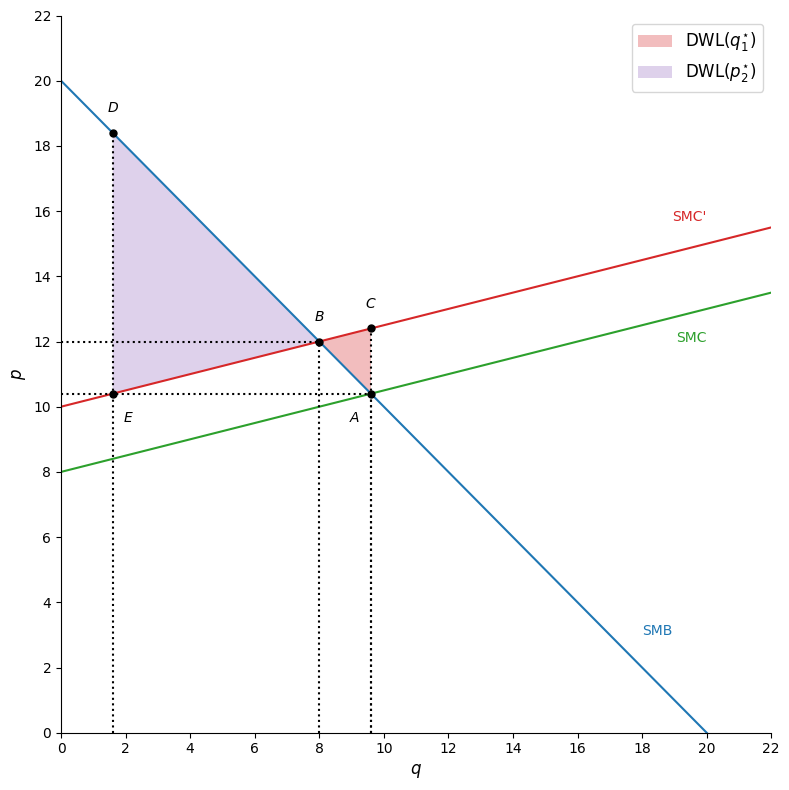

In [2]:
dwl_shift_diagram(
    shift="cost",
    params1=(20, 1, 8, 0.25),
    params2=(10, 0.25),
    point_offsets=[(-0.50, -0.75), (0.00, 0.75), (0.50, -0.75), (0.00, 0.75), (0.00, 0.75)],
    point_labels=["A", "B", "E", "D", "C"],
    curve_labels=[
        ("SMB", 18, 3, color_blue, "left"),
        ("SMC", 20, 12.0, color_green, "right"),
        ("SMC'", 20, 15.7, color_red, "right"),
    ],
    legend_loc="upper right",
    use_latex_points=True,
)

## 2. SMB shifts down

$SMC=8+0.25q$ (fixed); $SMB$ moves from $20-q$ to $15-q$.

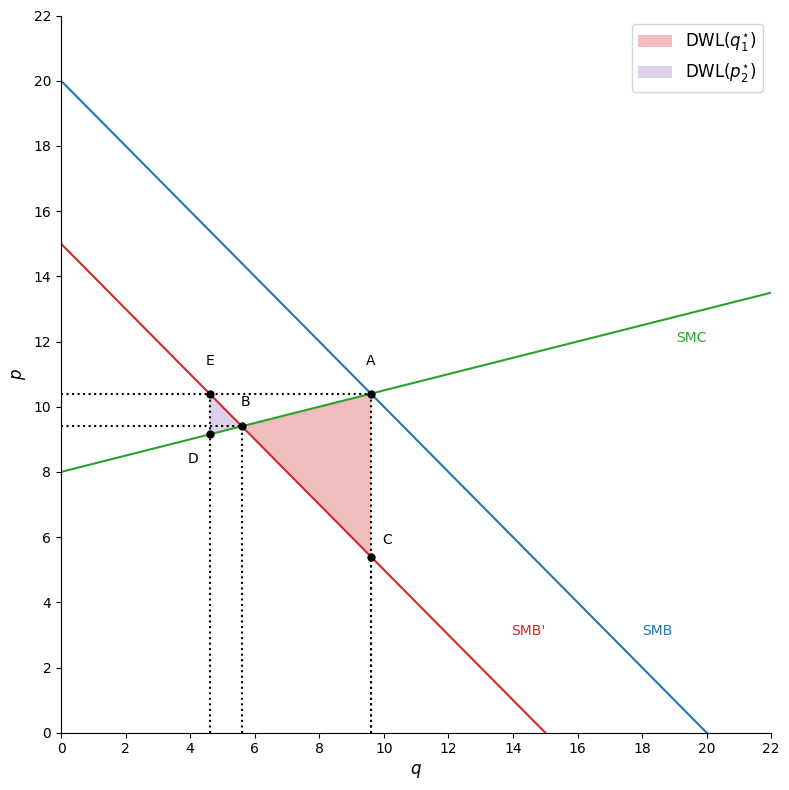

In [3]:
dwl_shift_diagram(
    shift="benefit",
    params1=(20, 1, 8, 0.25),
    params2=(15, 1),
    point_offsets=[(0.00, 1.00), (0.10, 0.75), (0.0, 1.0), (-0.5, -0.75), (0.5, 0.5)],
    point_labels=["A", "B", "E", "D", "C"],
    curve_labels=[
        ("SMB", 18, 3, color_blue, "left"),
        ("SMC", 20, 12.0, color_green, "right"),
        ("SMB'", 15, 3, color_red, "right"),
    ],
    legend_loc="upper right",
    use_latex_points=False,
)

## 3. SMB shifts up

$SMC=8+0.25q$ (fixed); $SMB$ moves from $20-q$ to $25-q$.

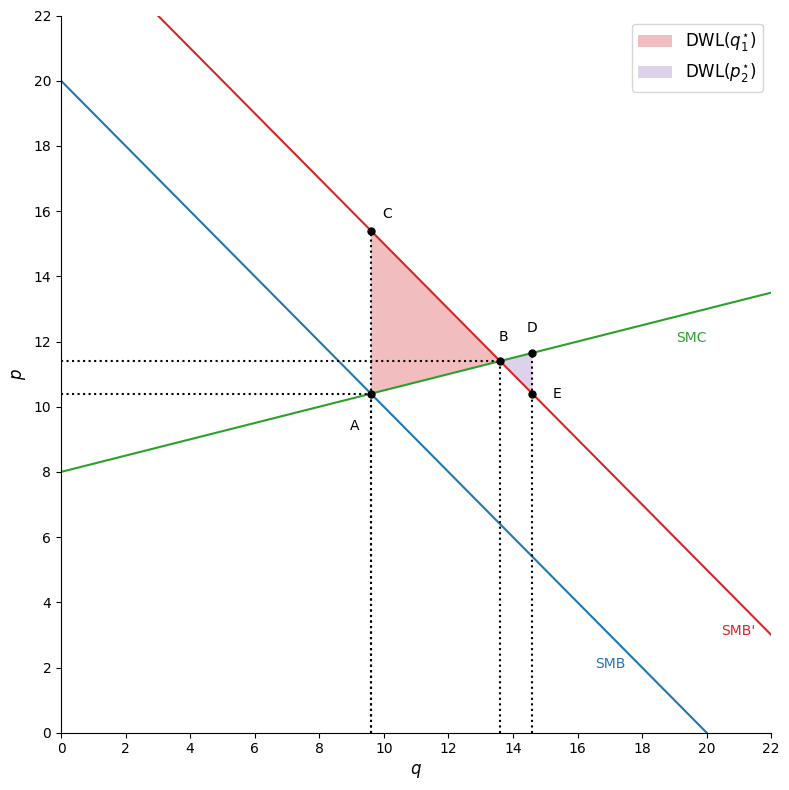

In [4]:
dwl_shift_diagram(
    shift="benefit",
    params1=(20, 1, 8, 0.25),
    params2=(25, 1),
    point_offsets=[(-0.50, -1.00), (0.10, 0.75), (0.75, 0.00), (0.00, 0.75), (0.50, 0.50)],
    point_labels=["A", "B", "E", "D", "C"],
    curve_labels=[
        ("SMB", 17.5, 2, color_blue, "right"),
        ("SMC", 20, 12.0, color_green, "right"),
        ("SMB'", 21.5, 3, color_red, "right"),
    ],
    legend_loc="upper right",
    use_latex_points=False,
)

## 4. SMC shifts up, steep slope

$SMB=18-0.5q$ (fixed); $SMC$ moves from $1+q$ to $7+q$ — a steeper pair
of curves than Section 1, showing the same construction generalizes.

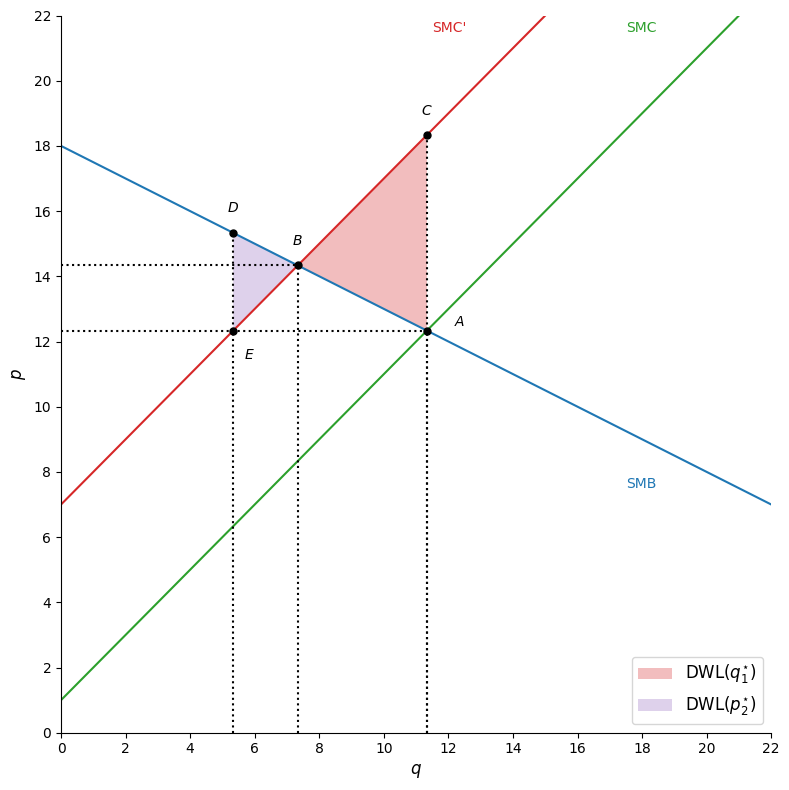

In [5]:
dwl_shift_diagram(
    shift="cost",
    params1=(18, 0.5, 1, 1.0),
    params2=(7, 1.0),
    point_offsets=[(1.00, 0.25), (0.00, 0.75), (0.50, -0.75), (0.00, 0.75), (0.00, 0.75)],
    point_labels=["A", "B", "E", "D", "C"],
    curve_labels=[
        ("SMB", 17.5, 7.5, color_blue, "left"),
        ("SMC", 17.5, 21.5, color_green, "left"),
        ("SMC'", 11.5, 21.5, color_red, "left"),
    ],
    legend_loc="lower right",
    use_latex_points=True,
)

## 5. SMB shifts down, steep slope

$SMC=1+q$ (fixed); $SMB$ moves from $18-0.5q$ to $15-0.5q$ — the mirror
comparative-static of Section 4.

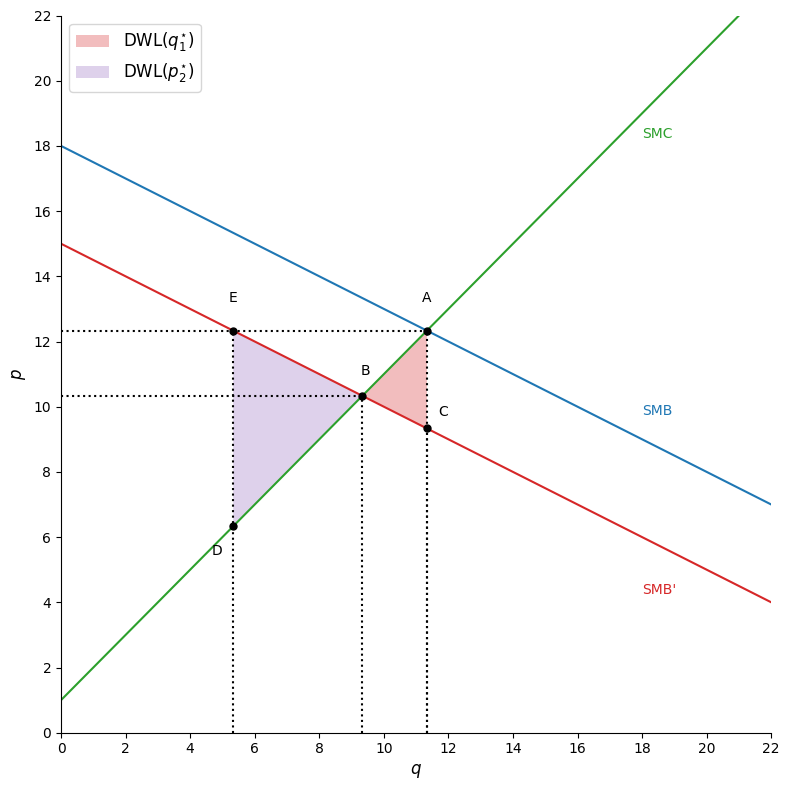

In [6]:
dwl_shift_diagram(
    shift="benefit",
    params1=(18, 0.5, 1, 1.0),
    params2=(15, 0.5),
    point_offsets=[(0.00, 1.00), (0.10, 0.75), (0.0, 1.0), (-0.5, -0.75), (0.5, 0.5)],
    point_labels=["A", "B", "E", "D", "C"],
    curve_labels=[
        ("SMB", 18, 9.75, color_blue, "left"),
        ("SMC", 18, 18.25, color_green, "left"),
        ("SMB'", 18, 4.25, color_red, "left"),
    ],
    legend_loc="upper left",
    use_latex_points=False,
)